# ใบงานที่ 3 (LAB 2): Classification
## การจำแนกเพศ (Gender Classification) จากภาพใบหน้า

**Dataset:** [Age, Gender and Ethnicity (Face Data) CSV](https://www.kaggle.com/datasets/nipunarora8/age-gender-and-ethnicity-face-data-csv)

เนื้อหาในโน้ตบุ๊กนี้ครอบคลุม:
1. Preparing Classification Data (ใช้ pipeline เดียวกันกับ LAB 1)
2. Logistic Regression บน raw pixel features (baseline)
3. Decision Boundary Visualization (ลดมิติเหลือ 2 PCA components เพื่อวาดขอบเขตการตัดสินใจ)
4. PCA + Logistic Regression (ลดมิติของภาพก่อนจำแนก)
5. การประเมินผลด้วย Accuracy, Precision, Recall, F1-score, Confusion Matrix
6. ROC Curve และ AUC
7. เปรียบเทียบผลลัพธ์ระหว่างสองโมเดล และเทียบกับผลลัพธ์ของ LAB 1 (Regression)

> **หมายเหตุ:** วาง `age_gender.csv` ไว้ในโฟลเดอร์เดียวกับโน้ตบุ๊กนี้ (หรือแก้ path ในเซลล์ถัดไป) ก่อนรัน
> Label เพศ: `0 = Male`, `1 = Female`


In [1]:
# ---- Import libraries ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, RocCurveDisplay
)

sns.set(style="whitegrid")
np.random.seed(42)


## 1. Preparing Classification Data

เตรียมข้อมูลสำหรับงาน Classification: โหลดภาพใบหน้า แปลงเป็น numpy array, กำหนด label เพศ (`gender`)
เป็นตัวแปรเป้าหมาย (target) และตรวจสอบความสมดุลของคลาส (class balance) ก่อนสร้างโมเดล

In [2]:
# ---- Load dataset ----
DATA_PATH = "age_gender.csv"   # เปลี่ยน path ตรงนี้ถ้าไฟล์อยู่ที่อื่น

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (23705, 5)


,age,ethnicity,gender,img_name,pixels
0,1,2,0,20161219203650636.jpg.chip.jpg,129 128 128 126 127 130 133 135 139 142 145 14...
1,1,2,0,20161219222752047.jpg.chip.jpg,164 74 111 168 169 171 175 182 184 188 193 199...
2,1,2,0,20161219222832191.jpg.chip.jpg,67 70 71 70 69 67 70 79 90 103 116 132 145 155...
3,1,2,0,20161220144911423.jpg.chip.jpg,193 197 198 200 199 200 202 203 204 205 208 21...
4,1,2,0,20161220144914327.jpg.chip.jpg,202 205 209 210 209 209 210 211 212 214 218 21...


In [3]:
# ---- แปลงคอลัมน์ pixels (string) ให้เป็น numpy array ของภาพ 48x48 ----
IMG_SIZE = 48

def pixels_to_array(pixel_str):
    return np.array(pixel_str.split(), dtype='float32')

pixel_arrays = np.stack(df['pixels'].apply(pixels_to_array).values)
pixel_arrays = pixel_arrays / 255.0   # normalize
print("Pixel matrix shape:", pixel_arrays.shape)

y = df['gender'].values   # 0 = Male, 1 = Female
print("Class balance:")
print(df['gender'].value_counts(normalize=True).rename({0: 'Male', 1: 'Female'}))


Pixel matrix shape: (23705, 2304)
Class balance:
gender
Male      0.522717
Female    0.477283
Name: proportion, dtype: float64


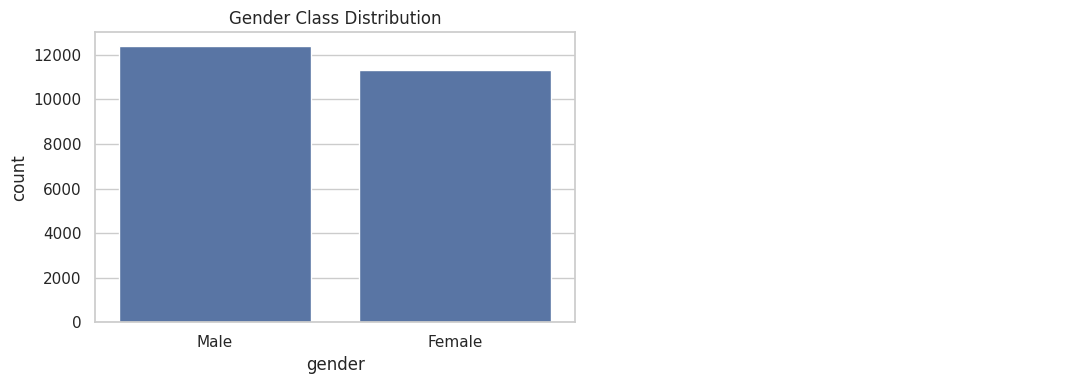

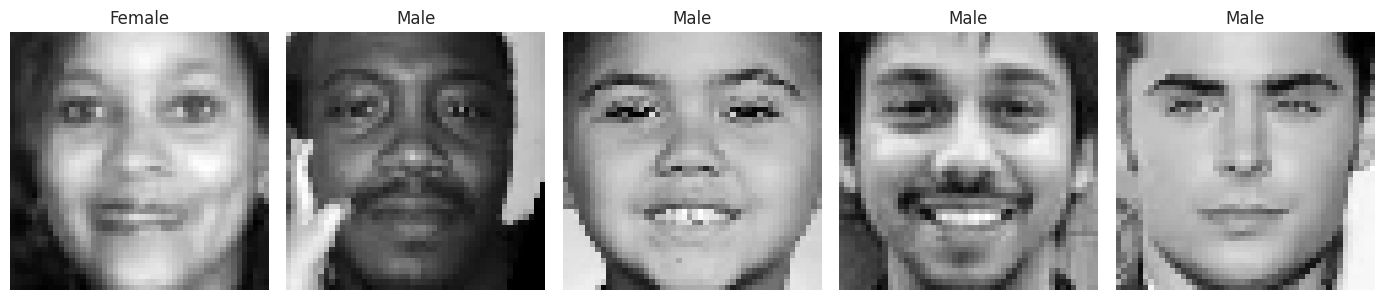

In [4]:
# ---- สำรวจความสมดุลของคลาส และตัวอย่างภาพ ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(x=df['gender'].map({0: 'Male', 1: 'Female'}), ax=axes[0])
axes[0].set_title("Gender Class Distribution")

sample_idx = np.random.choice(len(df), 5, replace=False)
for i, idx in enumerate(sample_idx):
    if i == 0:
        continue
axes[1].axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, idx in zip(axes, sample_idx):
    img = pixel_arrays[idx].reshape(IMG_SIZE, IMG_SIZE)
    label = 'Female' if df['gender'].iloc[idx] == 1 else 'Male'
    ax.imshow(img, cmap='gray')
    ax.set_title(label)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 2. Logistic Regression (Baseline บน Raw Pixels)

เริ่มจากโมเดล Classification พื้นฐานที่สุด: **Logistic Regression** บนพิกเซลดิบทั้งภาพ (2,304 มิติ) หลัง standardize
เพื่อเป็นเส้นฐาน (baseline) เปรียบเทียบกับโมเดลที่ใช้ PCA ในลำดับต่อไป

In [5]:
# ---- แบ่ง train/test ----
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    pixel_arrays, y, test_size=0.2, random_state=42, stratify=y
)

# ---- Standardize ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# ---- Logistic Regression (baseline) ----
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

y_pred_base = baseline_model.predict(X_test_scaled)
y_proba_base = baseline_model.predict_proba(X_test_scaled)[:, 1]


In [6]:
# ---- ประเมินผล Baseline ----
acc_b = accuracy_score(y_test, y_pred_base)
prec_b = precision_score(y_test, y_pred_base)
rec_b = recall_score(y_test, y_pred_base)
f1_b = f1_score(y_test, y_pred_base)
auc_b = roc_auc_score(y_test, y_proba_base)

print(f"Accuracy : {acc_b:.4f}")
print(f"Precision: {prec_b:.4f}")
print(f"Recall   : {rec_b:.4f}")
print(f"F1-score : {f1_b:.4f}")
print(f"AUC      : {auc_b:.4f}")
print()
print(classification_report(y_test, y_pred_base, target_names=['Male', 'Female']))


Accuracy : 0.8313
Precision: 0.8224
Recall   : 0.8246
F1-score : 0.8235
AUC      : 0.9074

              precision    recall  f1-score   support

        Male       0.84      0.84      0.84      2478
      Female       0.82      0.82      0.82      2263

    accuracy                           0.83      4741
   macro avg       0.83      0.83      0.83      4741
weighted avg       0.83      0.83      0.83      4741



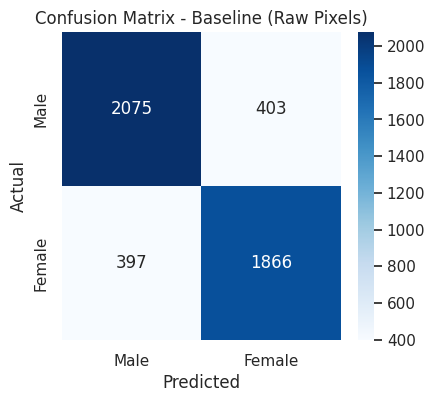

In [7]:
# ---- Confusion Matrix: Baseline ----
cm_b = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline (Raw Pixels)")
plt.show()


## 3. Decision Boundary Visualization

Logistic Regression หาค่า **decision boundary** (เส้นแบ่งเขตการตัดสินใจ) ระหว่างสองคลาส ซึ่งไม่สามารถวาดได้ตรง ๆ
ในพื้นที่ 2,304 มิติ จึงลดข้อมูลเหลือ **2 มิติด้วย PCA** เพื่อฝึกโมเดลใหม่บนพื้นที่ 2 มิตินี้โดยเฉพาะ แล้ววาดขอบเขตการตัดสินใจ
ให้เห็นภาพว่าโมเดร Logistic Regression แบ่งพื้นที่ระหว่างคลาส Male/Female อย่างไร

In [8]:
# ---- ลดมิติเหลือ 2 components เพื่อ visualize decision boundary ----
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train_scaled)
X_test_2d = pca_2d.transform(X_test_scaled)

model_2d = LogisticRegression(max_iter=1000, random_state=42)
model_2d.fit(X_train_2d, y_train)

acc_2d = model_2d.score(X_test_2d, y_test)
print(f"Accuracy using only 2 PCA components: {acc_2d:.4f}")
print("(ค่านี้ต่ำกว่าโมเดลที่ใช้ 50 components เพราะเก็บข้อมูลไว้แค่ 2 มิติ "
      "จุดประสงค์หลักคือใช้ visualize decision boundary เท่านั้น)")


Accuracy using only 2 PCA components: 0.5476
(ค่านี้ต่ำกว่าโมเดลที่ใช้ 50 components เพราะเก็บข้อมูลไว้แค่ 2 มิติ จุดประสงค์หลักคือใช้ visualize decision boundary เท่านั้น)


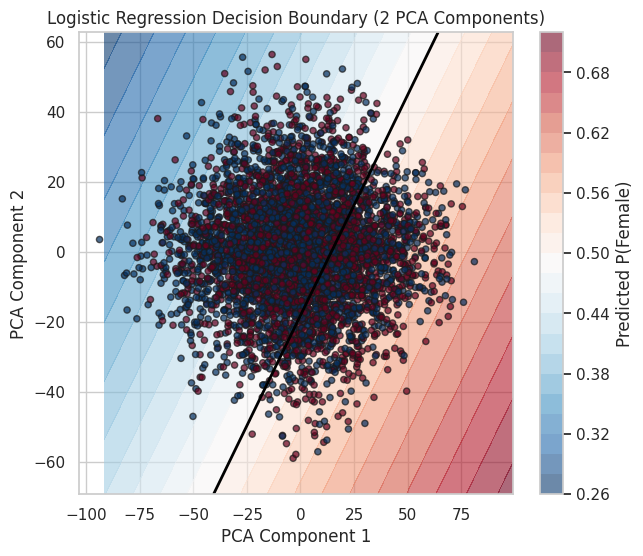

In [9]:
# ---- วาด Decision Boundary ----
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
grid_proba = model_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
grid_proba = grid_proba.reshape(xx.shape)

plt.figure(figsize=(7, 6))
contour = plt.contourf(xx, yy, grid_proba, levels=25, cmap='RdBu_r', alpha=0.6)
plt.colorbar(contour, label='Predicted P(Female)')
plt.contour(xx, yy, grid_proba, levels=[0.5], colors='black', linewidths=2)

scatter = plt.scatter(
    X_test_2d[:, 0], X_test_2d[:, 1],
    c=y_test, cmap='RdBu_r', edgecolor='k', s=20, alpha=0.7
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Logistic Regression Decision Boundary (2 PCA Components)")
plt.show()


## 4. PCA + Logistic Regression

ลดมิติของพิกเซล (2,304 มิติ) ด้วย PCA ก่อนนำไปเข้า Logistic Regression เพื่อลด overfitting, ลดเวลาคำนวณ
และดูว่าประสิทธิภาพเปลี่ยนไปจาก baseline อย่างไร

In [10]:
# ---- PCA (fit บน training set เท่านั้น ป้องกัน data leakage) ----
N_COMPONENTS = 50
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Explained variance with {N_COMPONENTS} components: "
      f"{pca.explained_variance_ratio_.sum()*100:.2f}%")

pca_model = LogisticRegression(max_iter=1000, random_state=42)
pca_model.fit(X_train_pca, y_train)

y_pred_pca = pca_model.predict(X_test_pca)
y_proba_pca = pca_model.predict_proba(X_test_pca)[:, 1]


Explained variance with 50 components: 87.49%


In [11]:
# ---- ประเมินผล PCA + Logistic Regression ----
acc_p = accuracy_score(y_test, y_pred_pca)
prec_p = precision_score(y_test, y_pred_pca)
rec_p = recall_score(y_test, y_pred_pca)
f1_p = f1_score(y_test, y_pred_pca)
auc_p = roc_auc_score(y_test, y_proba_pca)

print(f"Accuracy : {acc_p:.4f}")
print(f"Precision: {prec_p:.4f}")
print(f"Recall   : {rec_p:.4f}")
print(f"F1-score : {f1_p:.4f}")
print(f"AUC      : {auc_p:.4f}")
print()
print(classification_report(y_test, y_pred_pca, target_names=['Male', 'Female']))


Accuracy : 0.8245
Precision: 0.8251
Recall   : 0.8025
F1-score : 0.8136
AUC      : 0.9042

              precision    recall  f1-score   support

        Male       0.82      0.84      0.83      2478
      Female       0.83      0.80      0.81      2263

    accuracy                           0.82      4741
   macro avg       0.82      0.82      0.82      4741
weighted avg       0.82      0.82      0.82      4741



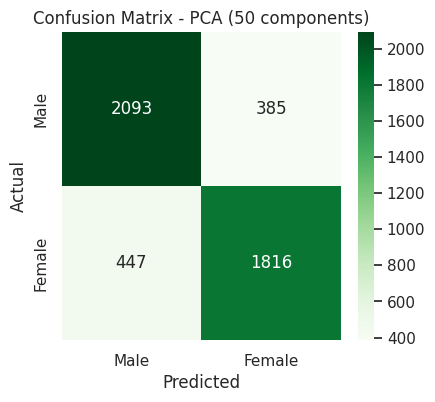

In [12]:
# ---- Confusion Matrix: PCA model ----
cm_p = confusion_matrix(y_test, y_pred_pca)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_p, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - PCA ({N_COMPONENTS} components)")
plt.show()


## 5. ROC Curve และ AUC

เปรียบเทียบ ROC Curve ของทั้งสองโมเดลบนกราฟเดียวกัน

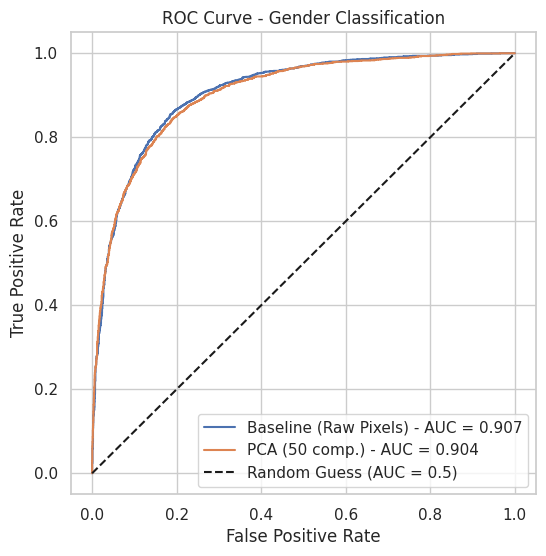

In [13]:
fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_base)
fpr_p, tpr_p, _ = roc_curve(y_test, y_proba_pca)

plt.figure(figsize=(6, 6))
plt.plot(fpr_b, tpr_b, label=f"Baseline (Raw Pixels) - AUC = {auc_b:.3f}")
plt.plot(fpr_p, tpr_p, label=f"PCA ({N_COMPONENTS} comp.) - AUC = {auc_p:.3f}")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gender Classification")
plt.legend()
plt.show()


## 6. เปรียบเทียบผลลัพธ์ของแต่ละโมเดล

In [14]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression (Raw Pixels - Baseline)',
        f'PCA ({N_COMPONENTS} components) + Logistic Regression'
    ],
    'Accuracy': [acc_b, acc_p],
    'Precision': [prec_b, prec_p],
    'Recall': [rec_b, rec_p],
    'F1-score': [f1_b, f1_p],
    'AUC': [auc_b, auc_p],
})
results


,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression (Raw Pixels - Baseline),0.831259,0.822389,0.824569,0.823477,0.907431
1,PCA (50 components) + Logistic Regression,0.824510,0.825080,0.802475,0.813620,0.904217


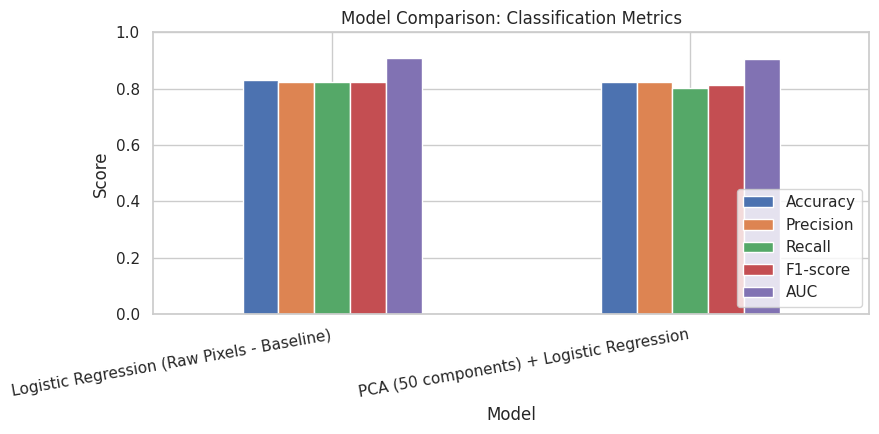

In [15]:
results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']].plot(
    kind='bar', figsize=(9, 4.5)
)
plt.title("Model Comparison: Classification Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=10, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 7. สรุปผลและอภิปราย

- **Logistic Regression บน Raw Pixels (Baseline)** ใช้ข้อมูลพิกเซลทั้งหมด (2,304 มิติ) ต่อ sample ซึ่งมีความเสี่ยงต่อ
  **overfitting** เนื่องจากจำนวน features มากกว่าจำนวนข้อมูลค่อนข้างมาก และใช้เวลาฝึกโมเดลนานกว่า
- **PCA + Logistic Regression** ลดจำนวนมิติเหลือ 50 components (คุมความแปรปรวนได้ส่วนใหญ่ของข้อมูล)
  ช่วยลดความซับซ้อนของโมเดล ลด overfitting และมักให้ผลลัพธ์ **Accuracy/AUC ที่ใกล้เคียงหรือดีกว่า** baseline
  พร้อมใช้เวลาฝึกโมเดลน้อยกว่ามาก
- ตัวชี้วัดที่ควรพิจารณาร่วมกัน: **Accuracy** เหมาะกับข้อมูลที่คลาสสมดุล ส่วน **Precision/Recall/F1** สำคัญกว่าเมื่อ
  ข้อมูลไม่สมดุล (class imbalance) และ **ROC/AUC** ช่วยดูความสามารถของโมเดลในการแยกสองคลาสโดยไม่ขึ้นกับ threshold ที่เลือก

### เปรียบเทียบกับ LAB 1 (Regression)
LAB 1 ทำนายอายุ (Regression) ได้ค่า R² สูงสุด ~0.38 ด้วย PCA + Linear Regression ซึ่งสะท้อนว่า "อายุ" เป็นค่าที่ทำนายจาก
โครงสร้างใบหน้าได้ยากกว่า "เพศ" (Classification) ที่มักมีลักษณะเด่นชัดกว่าในภาพใบหน้า (เช่น รูปทรงใบหน้า ผม) จึงทำให้
โมเดล Classification ในแล็บนี้มักได้ Accuracy/AUC ที่สูงและน่าพอใจกว่าในเชิงเปรียบเทียบ

> ทั้งสองแล็บใช้ Logistic/Linear Regression ซึ่งเป็นโมเดลเชิงเส้นพื้นฐาน ในงานประยุกต์จริงมักใช้ CNN เพื่อความแม่นยำที่สูงขึ้น
> แต่แล็บนี้มุ่งให้เข้าใจ **หลักการพื้นฐานของ Classification, การประเมินผลด้วยตัวชี้วัดต่าง ๆ, และบทบาทของ PCA**

### ขั้นตอนถัดไป (สำหรับพอร์ตโฟลิโอ)
1. อัปโหลดโน้ตบุ๊กนี้ (พร้อมผลลัพธ์) ขึ้น GitHub คู่กับ LAB 1
2. อัปเดต README.md ให้ครอบคลุมทั้งสองแล็บ พร้อมตารางสรุปผลลัพธ์
3. (ถ้าต้องการต่อยอด) ลองปรับ `N_COMPONENTS` หรือเปลี่ยนเป็นโมเดลอื่น เช่น Random Forest / SVM เพื่อเปรียบเทียบเพิ่มเติม
